In [26]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'


In [27]:
 
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata_icefront.txt'

# Generate loop_info DataFrame

In [28]:
df_ms = pd.read_csv('./tables/linear_meltsensetivity_first50years.csv')
df_time80 = pd.read_csv('./tables/time_80precentofIceShelf.csv')

df_m2100 = pd.read_csv('./tables/averegeshelfmelt_2100.csv')
df_m2200 = pd.read_csv('./tables/averegeshelfmelt_2200.csv')
df_m2300 = pd.read_csv('./tables/averegeshelfmelt_2300.csv')


df_bmb2100 = pd.read_csv('./tables/totalshelfmelt_2100.csv')
df_bmb2200 = pd.read_csv('./tables/totalshelfmelt_2200.csv')
df_bmb2300 = pd.read_csv('./tables/totalshelfmelt_2300.csv')
df_info = pd.read_csv(metadata_file)                 


In [29]:
grouped = df_ms.groupby('Model')

In [30]:
Models = df_ms[df_ms['Experiment']== 'expAE02'].Model

In [31]:
Models.index

Int64Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
            17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
            34, 35],
           dtype='int64')

In [32]:
df_info

,Unnamed: 0,Group,Model,Experiment,Climate Forcing,Model setup,fileID,Main submission,Melt parameterisation,Melt parameters,Resolution,Resolution GL,GL treatment,GL melt,ice front
0,0,DC,ISSM,ctrlAE,ctrl,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
1,1,DC,ISSM,expAE02,CCSM4,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
2,2,DC,ISSM,expAE03,HadGEM2,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
3,3,DC,ISSM,expAE04,CESM2,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
4,4,DC,ISSM,expAE05,UKESM,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,210,VUW,PISM,ctrlAE,ctrl,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
211,211,VUW,PISM,expAE02,CCSM4,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
212,212,VUW,PISM,expAE03,HadGEM2,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
213,213,VUW,PISM,expAE04,CESM2,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR


Text(0, 0.5, 'melt sens.')

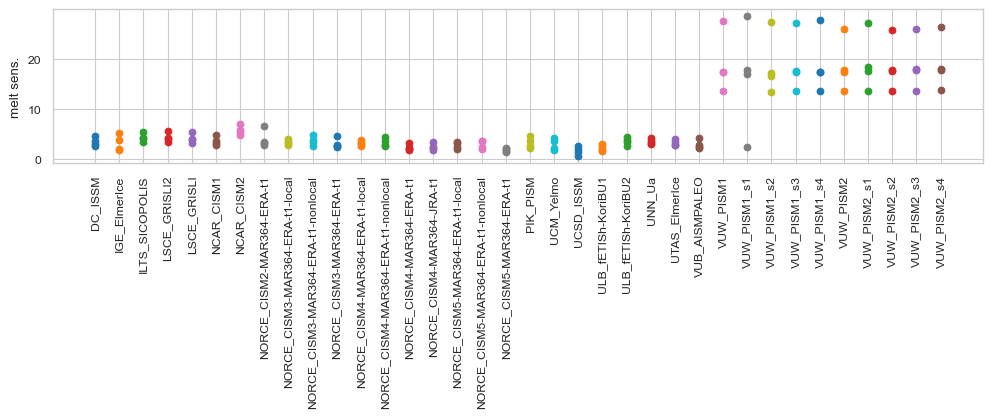

In [33]:
f,ax = plt.subplots(1,1, figsize = (12,2), sharex = True)
for i,Mod in enumerate(Models):
    ax.scatter([i,i,i,i],df_ms[df_ms['Model']== Mod].AIS.values)
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
ax.set_ylabel('melt sens.')
    
    


## The linear melt sensetivity  spreads for the four different experimets. Ideally they would be the same , this is also true for different sectors. Very high melt sensetivity for all VUW PISM runs. Compared to others Models that is also true for sector 2 and 5 , sector 3 and 4  other models PIK PISM and UCIS ISSM have also strong climate sensetivity.

Text(0, 0.5, 'melt sens.')

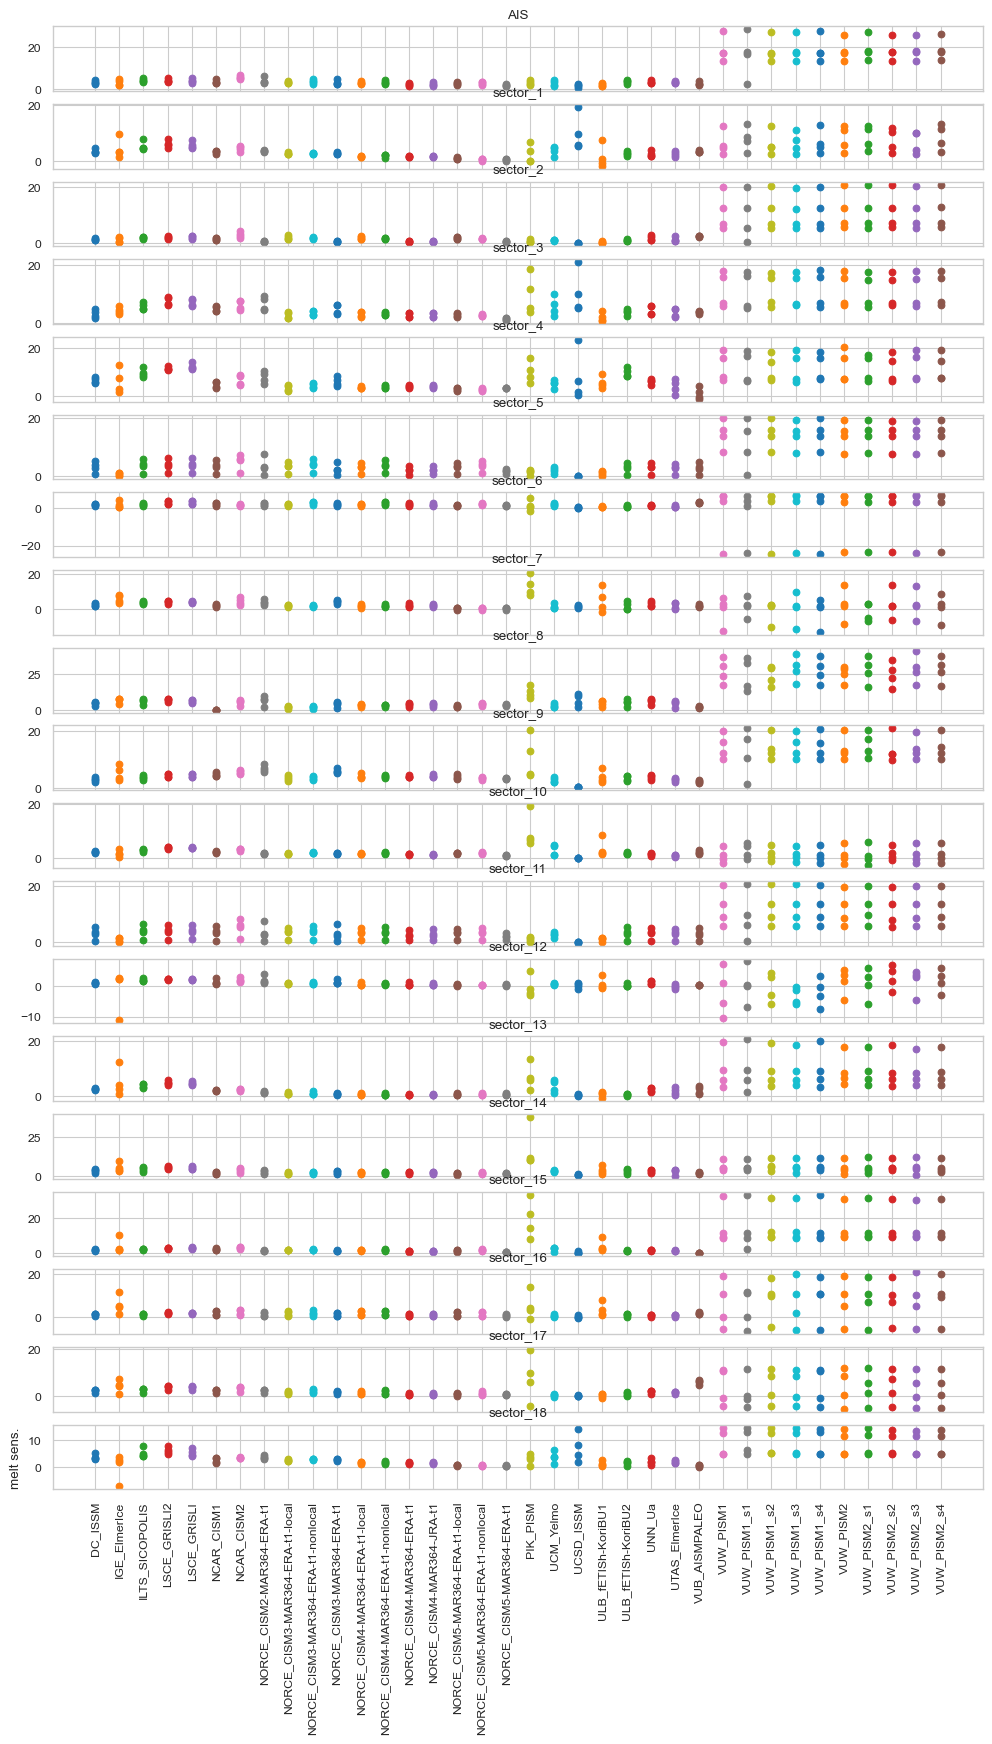

In [34]:
f,ax = plt.subplots(19,1, figsize = (12,19), sharex = True)
for i,Mod in enumerate(Models):
    dfmodel = df_ms[df_ms['Model']== Mod]
    ax[0].scatter([i,i,i,i],dfmodel.AIS.values)
    ax[0].set_xticks(Models.index)
    ax[0].set_title('AIS')
    for j in range(1,19):
        ax[j].scatter([i,i,i,i],dfmodel['sector_'+str(j)].values)
        ax[j].set_title('sector_'+str(j))
        
ax[18].set_xticklabels(Models, rotation=90)
ax[18].set_ylabel('melt sens.')
    
    


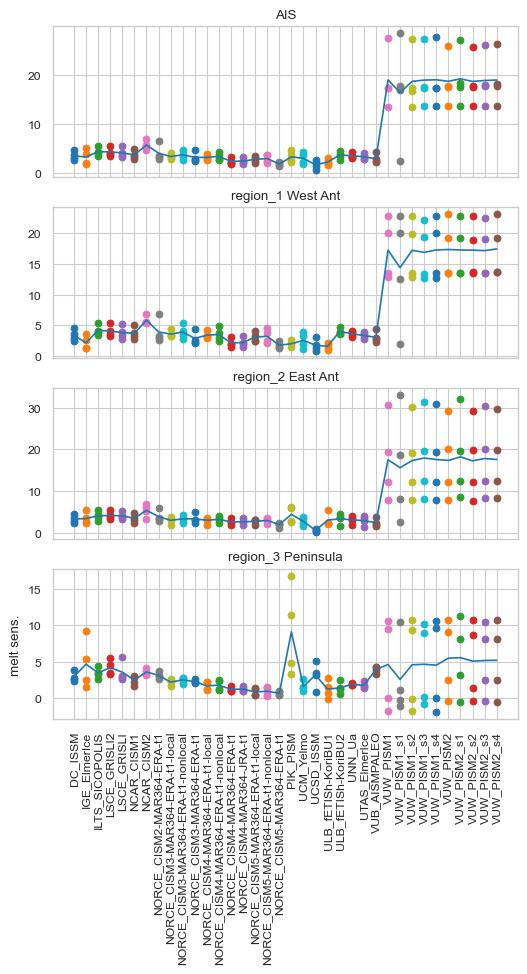

In [43]:
# let us check for west eact and pneinusla
dic_ms_means={}
region_names = ['West Ant','East Ant','Peninsula']
f,ax = plt.subplots(4,1, figsize = (6,9), sharex = True)
means = np.zeros(len(Models))
for i in range(4):
    dic_ms_means[i]=means.copy()
for i,Mod in enumerate(Models):
    
    dfmodel = df_ms[df_ms['Model']== Mod]
    ax[0].scatter([i,i,i,i],dfmodel.AIS.values)
    ax[0].set_xticks(Models.index)
    ax[0].set_title('AIS')
    
    
    dic_ms_means[0][i] = dfmodel.AIS.values.mean()
    

    for j in range(1,4):
        ax[j].scatter([i,i,i,i],dfmodel['region_'+str(j)].values)
        ax[j].set_title('region_'+str(j) +' ' +region_names[j-1], )
        dic_ms_means[j][i]=dfmodel['region_'+str(j)].values.mean()
        
ax[3].set_xticklabels(Models, rotation=90)
ax[3].set_ylabel('melt sens.')
for i in range(4):
    ax[i].plot(np.arange(0,len(Models)),dic_ms_means[i])  

In [40]:
dic_ms_means[3]

array([2.91466183, 4.64934118, 3.44818115, 4.16873752, 3.54837167,
       2.46429996, 3.57506697, 3.12333552, 2.17899916, 2.48873909,
       2.24804302, 1.66866739, 1.7563829 , 1.19537706, 1.21739363,
       0.83234066, 0.93032668, 0.63310269, 9.09002105, 1.58486429,
       3.16614522, 1.2217089 , 1.38361385, 1.87070146, 1.75304937,
       3.90328595, 4.60388899, 2.54171312, 4.56513338, 4.63181697,
       4.51338644, 5.47286886, 5.5357077 , 5.06198707, 5.14784379,
       5.18312474])

In [45]:
df_info_dropped = df_info.copy()
droplist = []
for i in range(df_info_dropped.shape[0]):

    if df_info_dropped.iloc[i].fileID in removeFileID:
        droplist.append(i)
    else:
        continue
df_info_dropped = df_info_dropped.drop(index=droplist)
melt_paramin  = df_info_dropped[df_info_dropped.Experiment == 'expAE02']['Melt parameterisation']
melt_param = melt_paramin.reset_index(drop=True)
Prams_u =melt_param.unique()
# mfix = ice_front == 'Fix'
# ice_front[mfix]

In [52]:
Prams_u

array(['Quad. Non-local', 'PICO', 'Quad. Local', 'Quad. Non-local Slope',
       'PICOP', 'Lin'], dtype=object)

[Text(0, 0, 'Quad. Non-local'),
 Text(1, 0, 'PICO'),
 Text(2, 0, 'Quad. Local'),
 Text(3, 0, 'Quad. Non-local Slope'),
 Text(4, 0, 'PICOP'),
 Text(5, 0, 'Lin')]

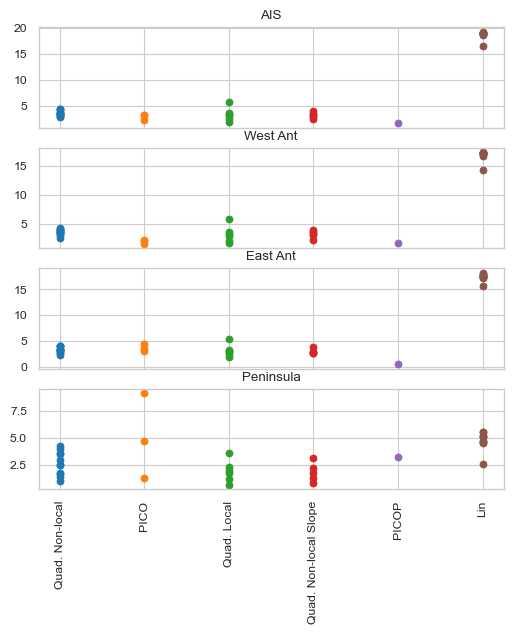

In [61]:
region_names = ['AIS','West Ant','East Ant','Peninsula']
f,ax = plt.subplots(4,1, figsize = (6,6), sharex = True)
for i in range(4):
    for j,param in enumerate(Prams_u):
        mparam = param == melt_param 
        vals = dic_ms_means[i][mparam]
        x = np.zeros(len(vals))
        x = x+j
 
        ax[i].scatter(x,vals)
        ax[i].set_title(region_names[i])
ax[i].set_xticks(np.arange(0,6))
ax[i].set_xticklabels(Prams_u, rotation=90) 

### Let us takte the mean with all the four values and check wether the ba

In [62]:
df_ms_mean =  df_ms[df_ms['Experiment']== 'expAE02']
df_ms_mean = df_ms_mean.drop(columns=['Experiment'])
df_ms_mean = df_ms_mean.drop(columns=['Path'])

In [63]:

for i,Mod in enumerate(Models):
    dfmodel = df_ms[df_ms['Model']== Mod]
    df_ms_mean.loc[df_ms_mean['Model'] == Mod, 'AIS'] = dfmodel.AIS.values.mean()

    for j in range(1,19):
        df_ms_mean.loc[df_ms_mean['Model'] == Mod, 'sector_'+str(j)]  =dfmodel['sector_'+str(j)].values.mean()


Text(0.5, 1.0, 'standardized melt sensetiviy ')

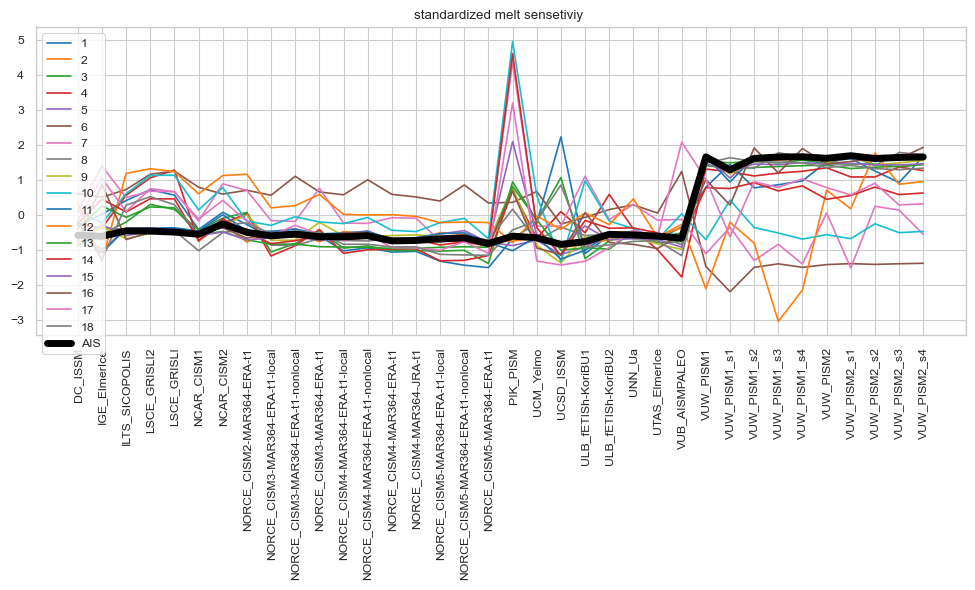

In [64]:
f,ax = plt.subplots(1,1,figsize =( 12,4))

for j in range(1,19):
    y = df_ms_mean['sector_'+str(j)].values
    mnan = np.isnan(y)
    y_m = y[~mnan].mean()
    std = y[~mnan].std()
    y = y -y_m
    y =y/std
    ax.plot(Models.index,y,label = j)
y = df_ms_mean.AIS.values
mnan = np.isnan(y)
y_m = y[~mnan].mean()
std = y[~mnan].std()
y = y -y_m
y =y/std
ax.plot(Models.index,y,lw = '5',label = 'AIS', color = 'black')
ax.set_xticks(Models.index)
        
ax.set_xticklabels(Models, rotation=90)
ax.legend(loc = 2,)
ax.set_title('standardized melt sensetiviy ')

In [65]:
isort = np.argsort(y)

In [66]:
Models[isort[::-1]]

32                          VUW_PISM2_s1
30                          VUW_PISM1_s4
26                             VUW_PISM1
35                          VUW_PISM2_s4
29                          VUW_PISM1_s3
34                          VUW_PISM2_s3
31                             VUW_PISM2
28                          VUW_PISM1_s2
33                          VUW_PISM2_s2
27                          VUW_PISM1_s1
6                             NCAR_CISM2
2                         ILTS_SICOPOLIS
3                           LSCE_GRISLI2
4                            LSCE_GRISLI
7              NORCE_CISM2-MAR364-ERA-t1
9     NORCE_CISM3-MAR364-ERA-t1-nonlocal
5                             NCAR_CISM1
22                    ULB_fETISh-KoriBU2
23                                UNN_Ua
0                                DC_ISSM
12    NORCE_CISM4-MAR364-ERA-t1-nonlocal
8        NORCE_CISM3-MAR364-ERA-t1-local
24                         UTAS_ElmerIce
18                              PIK_PISM
1               



### Standardized melt sensetiviy for AIS reveals most sensetiv modes. Hoever the relativ AIS sensetivitu factor are not always representet as for the same secotrs 1-19. nonethless let us use AIS for melting

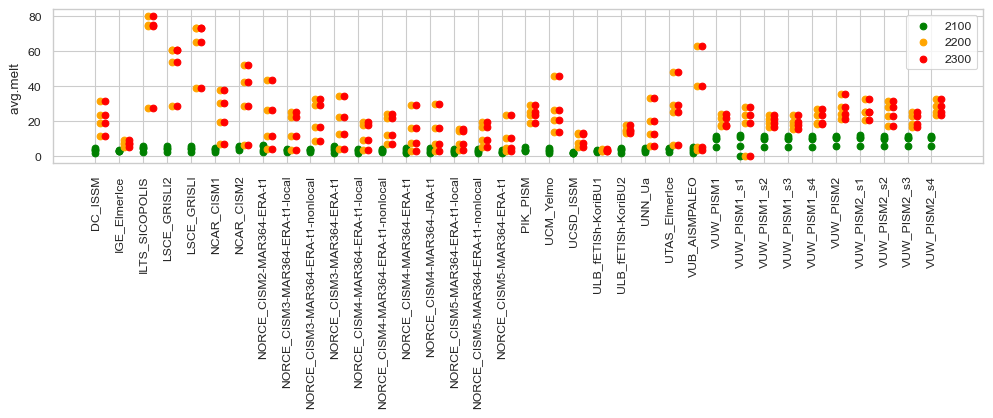

In [67]:
f,ax = plt.subplots(1,1, figsize = (12,2), sharex = True)
for i,Mod in enumerate(Models):
    dftemp = df_m2100
    ax.scatter([i,i,i,i],dftemp [dftemp ['Model']== Mod].AIS.values,color = 'green',label='2100' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
for i,Mod in enumerate(Models):
    dftemp = df_m2300
    it = i+0.2
    ax.scatter([it,it,it,it],dftemp [dftemp ['Model']== Mod].AIS.values ,color = 'orange',label='2200' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
for i,Mod in enumerate(Models):
    dftemp = df_m2300
    it = i+0.4

    ax.scatter([it,it,it,it],dftemp [dftemp ['Model']== Mod].AIS.values, color = 'red',label='2300' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
ax.set_ylabel('avg.melt ')
    
ax.legend()


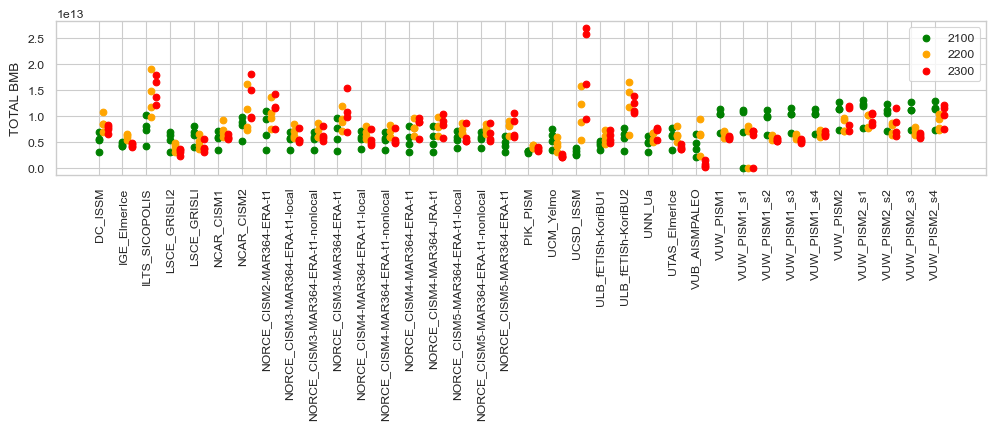

In [68]:
f,ax = plt.subplots(1,1, figsize = (12,2), sharex = True)
for i,Mod in enumerate(Models):
    dftemp = df_bmb2100
    ax.scatter([i,i,i,i],dftemp [dftemp ['Model']== Mod].AIS.values,color = 'green',label='2100' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
for i,Mod in enumerate(Models):
    dftemp = df_bmb2200
    it = i+0.2
    ax.scatter([it,it,it,it],dftemp [dftemp ['Model']== Mod].AIS.values ,color = 'orange',label='2200' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
for i,Mod in enumerate(Models):
    dftemp = df_bmb2300
    it = i+0.4

    ax.scatter([it,it,it,it],dftemp [dftemp ['Model']== Mod].AIS.values, color = 'red',label='2300' if i == 0 else "")
    ax.set_xticks(Models.index)
    ax.set_xticklabels(Models, rotation=90)
ax.set_ylabel('TOTAL BMB')
    
ax.legend()

Text(0.5, 0, 'melt sensetivity')

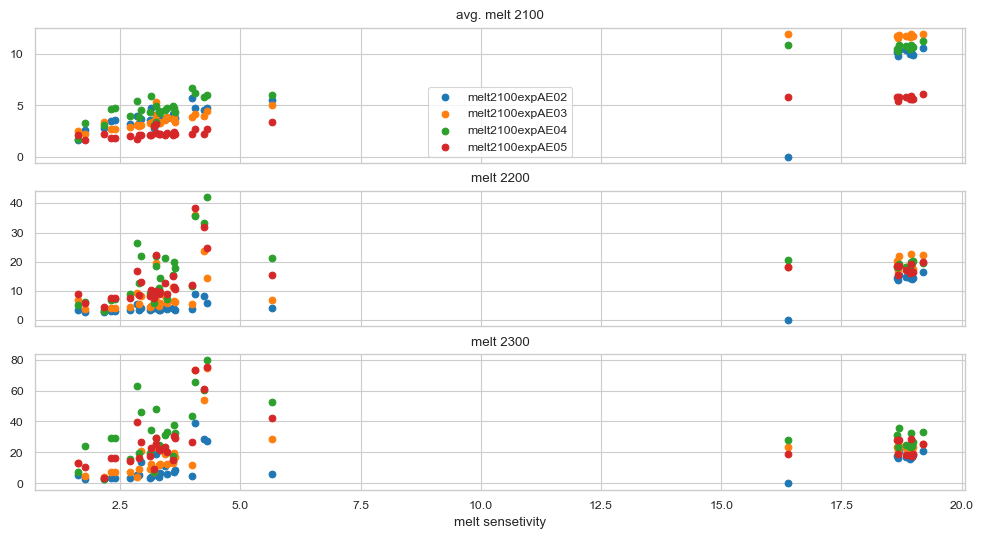

In [77]:
f,ax = plt.subplots(3,1, figsize = (12,6), sharex = True)
i =0
dftemp = df_m2100
ax[i].set_title('avg. melt 2100')
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')

i =1 
dftemp = df_m2200
ax[i].set_title('melt 2200')
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')

i =2
dftemp = df_m2300
ax[i].set_title('melt 2300')
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')
ax[0].legend()
ax[2].set_xlabel("melt sensetivity")

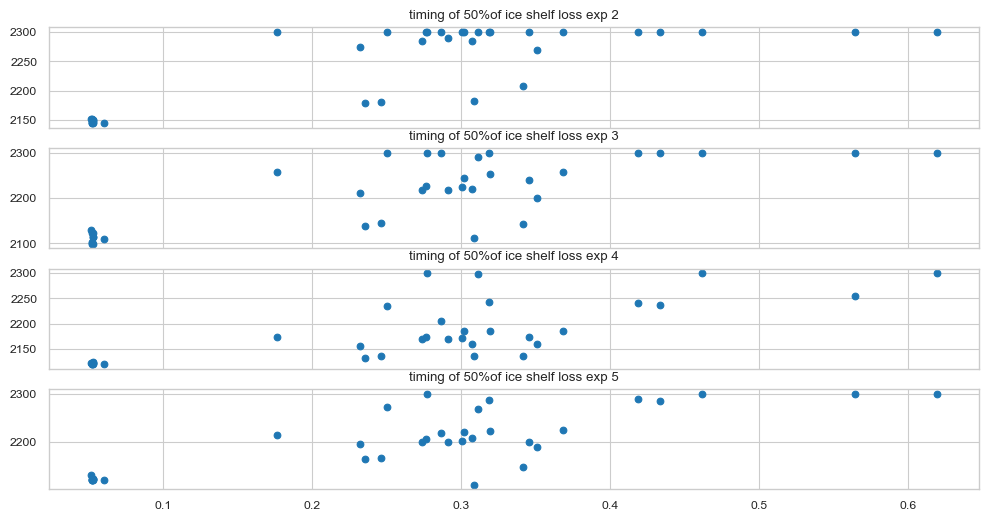

In [69]:
f,ax2 = plt.subplots(4,1, figsize = (12,6), sharex = True)
i =0
cfrac = 0.5
dftime= pd.read_csv('tables/time_'+str(cfrac)+'ofIceShelf.csv')
dftemp = dftime
ax = ax2[0]
ax.set_title('timing of 50%of ice shelf loss exp 2')
y =dftemp[dftemp['Experiment' ]== 'expAE02'].region_1.values
ax.scatter(1/df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
ax = ax2[1]
ax.set_title('timing of 50%of ice shelf loss exp 3')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].region_1.values
ax.scatter(1/df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
ax = ax2[2]
ax.set_title('timing of 50%of ice shelf loss exp 4')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].region_1.values
ax.scatter(1/df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
ax = ax2[3]
ax.set_title('timing of 50%of ice shelf loss exp 5')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].region_1.values
ax.scatter(1/df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')

In [72]:
df_info_dropped = df_info.copy()
droplist = []
for i in range(df_info_dropped.shape[0]):

    if df_info_dropped.iloc[i].fileID in removeFileID:
        droplist.append(i)
    else:
        continue
df_info_dropped = df_info_dropped.drop(index=droplist)
ice_front1 = df_info_dropped[df_info_dropped.Experiment == 'expAE02']['ice front']
ice_front = ice_front1.reset_index(drop=True)
mfix = ice_front == 'Fix'
ice_front[mfix]

1     Fix
20    Fix
24    Fix
Name: ice front, dtype: object

In [73]:
ice_front.size

36

In [77]:
Models

0                                DC_ISSM
1                           IGE_ElmerIce
2                         ILTS_SICOPOLIS
3                           LSCE_GRISLI2
4                            LSCE_GRISLI
5                             NCAR_CISM1
6                             NCAR_CISM2
7              NORCE_CISM2-MAR364-ERA-t1
8        NORCE_CISM3-MAR364-ERA-t1-local
9     NORCE_CISM3-MAR364-ERA-t1-nonlocal
10             NORCE_CISM3-MAR364-ERA-t1
11       NORCE_CISM4-MAR364-ERA-t1-local
12    NORCE_CISM4-MAR364-ERA-t1-nonlocal
13             NORCE_CISM4-MAR364-ERA-t1
14             NORCE_CISM4-MAR364-JRA-t1
15       NORCE_CISM5-MAR364-ERA-t1-local
16    NORCE_CISM5-MAR364-ERA-t1-nonlocal
17             NORCE_CISM5-MAR364-ERA-t1
18                              PIK_PISM
19                             UCM_Yelmo
20                             UCSD_ISSM
21                    ULB_fETISh-KoriBU1
22                    ULB_fETISh-KoriBU2
23                                UNN_Ua
24              

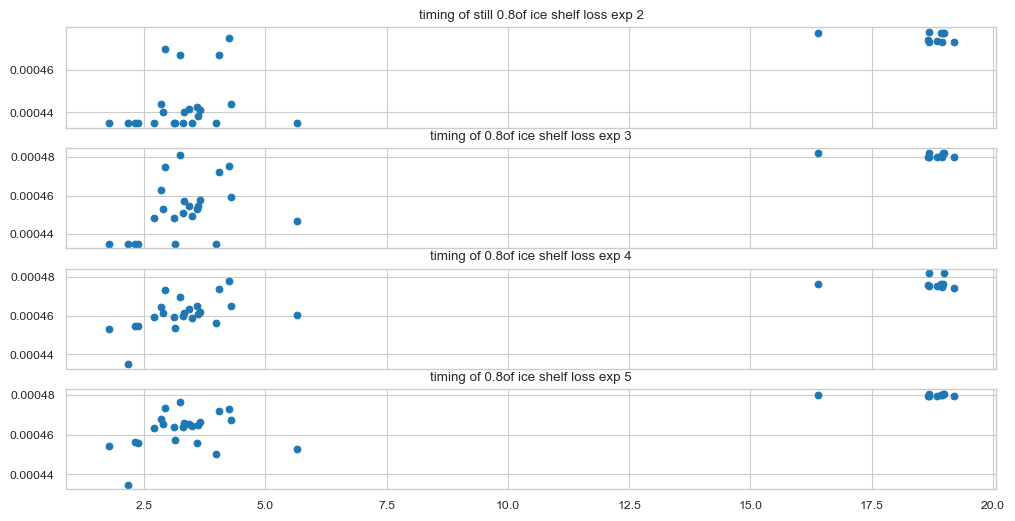

In [122]:
f,ax2 = plt.subplots(4,1, figsize = (12,6), sharex = True)
i =0
cfrac = 0.8
dftime= pd.read_csv('tables/time_'+str(cfrac)+'ofIceShelf.csv')
dftemp = dftime
ax = ax2[0]
ax.set_title('timing of still '+str(cfrac)+'of ice shelf loss exp 2')
y =dftemp[dftemp['Experiment' ]== 'expAE02'].region_1.values
ax.scatter(df_ms_mean.AIS.values[~mfix],1/y[~mfix], label = 'melt2100' + 'expAE02')
ax = ax2[1]
ax.set_title('timing of '+str(cfrac)+'of ice shelf loss exp 3')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].region_1.values
ax.scatter(df_ms_mean.AIS.values[~mfix],1/y[~mfix], label = 'melt2100' + 'expAE03')
ax = ax2[2]
ax.set_title('timing of '+str(cfrac)+'of ice shelf loss exp 4')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].region_1.values
ax.scatter(df_ms_mean.AIS.values[~mfix],1/y[~mfix], label = 'melt2100' + 'expAE04')
ax = ax2[3]
ax.set_title('timing of '+str(cfrac)+'of ice shelf loss exp 5')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].region_1.values
ax.scatter(df_ms_mean.AIS.values[~mfix],1/y[~mfix], label = 'melt2100' + 'expAE05')
models_nofix = Models[~mfix].reset_index(drop=True)
# for j in range(len(y[~mfix])):
    
#     ax.annotate(models_nofix[j],(df_ms_mean.AIS.values[~mfix][j],1/y[~mfix][j]),rotation = 90)
#     ax.annotate('test',(df_ms_mean.AIS.values[~mfix][j],1/y[~mfix][j]))
    


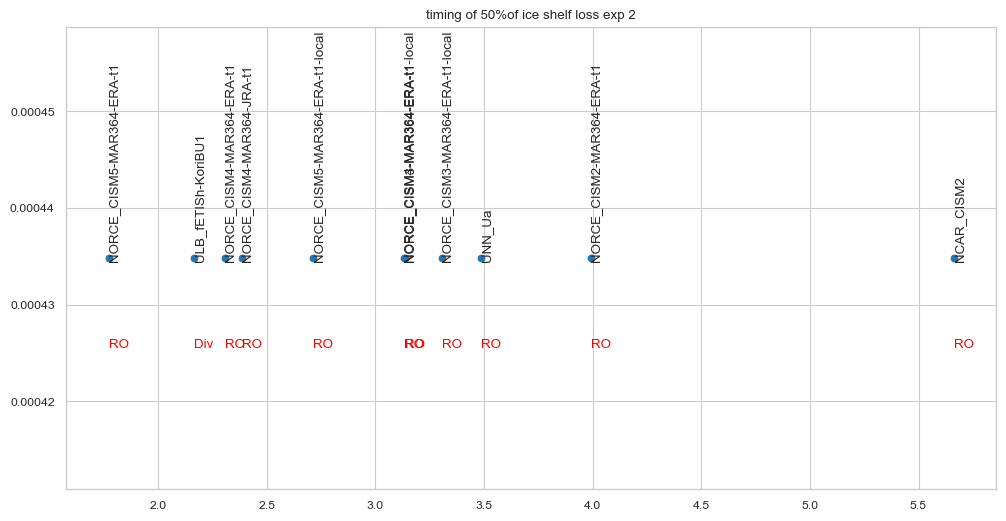

In [123]:
f,ax = plt.subplots(1,1, figsize = (12,6), sharex = True)
i =0
cfrac = 0.8
dftime= pd.read_csv('tables/time_'+str(cfrac)+'ofIceShelf.csv')
dftemp = dftime
# ax = ax2[0]
ax.set_title('timing of 50%of ice shelf loss exp 2')
y =dftemp[dftemp['Experiment' ]== 'expAE02'].region_1.values
m300 = y[~mfix] == 2300

ax.scatter(df_ms_mean.AIS.values[~mfix][m300],1/y[~mfix][m300], label = 'melt2100' + 'expAE02')

models_nofix = Models[~mfix][m300].reset_index(drop=True)
ice_frontnofix =ice_front[~mfix][m300].reset_index(drop=True)
for j in range(len(y[~mfix][m300])):
    
    ax.annotate(models_nofix[j],(df_ms_mean.AIS.values[~mfix][m300][j],1/y[~mfix][m300][j]),rotation = 90)
    ax.annotate(ice_frontnofix[j],(df_ms_mean.AIS.values[~mfix][m300][j],1/2350),color = 'red')
    

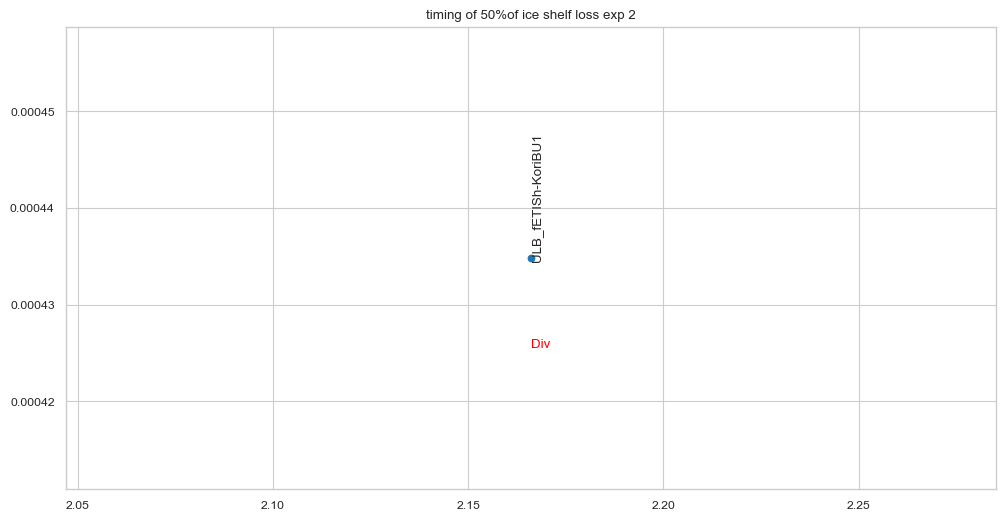

In [125]:
f,ax = plt.subplots(1,1, figsize = (12,6), sharex = True)
i =0
cfrac = 0.8
dftime= pd.read_csv('tables/time_'+str(cfrac)+'ofIceShelf.csv')
dftemp = dftime
# ax = ax2[0]
ax.set_title('timing of 50%of ice shelf loss exp 2')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].region_1.values
m300 = y[~mfix] == 2300

ax.scatter(df_ms_mean.AIS.values[~mfix][m300],1/y[~mfix][m300], label = 'melt2100' + 'expAE02')

models_nofix = Models[~mfix][m300].reset_index(drop=True)
ice_frontnofix =ice_front[~mfix][m300].reset_index(drop=True)
for j in range(len(y[~mfix][m300])):
    
    ax.annotate(models_nofix[j],(df_ms_mean.AIS.values[~mfix][m300][j],1/y[~mfix][m300][j]),rotation = 90)
    ax.annotate(ice_frontnofix[j],(df_ms_mean.AIS.values[~mfix][m300][j],1/2350),color = 'red')
    

### Ich shelf does retreat only little with RO , with retreat only scenario whatever that means! and DIv divergence and accumulation damage.


In [ ]:
# I think that the models wiht very high melt sensetivit loose their ice sheet already in 2100 or so.
# Can we attribute this high melt sensetivity to a certain parameter ? or frocing 

Text(0.5, 0, 'melt sensetivity')

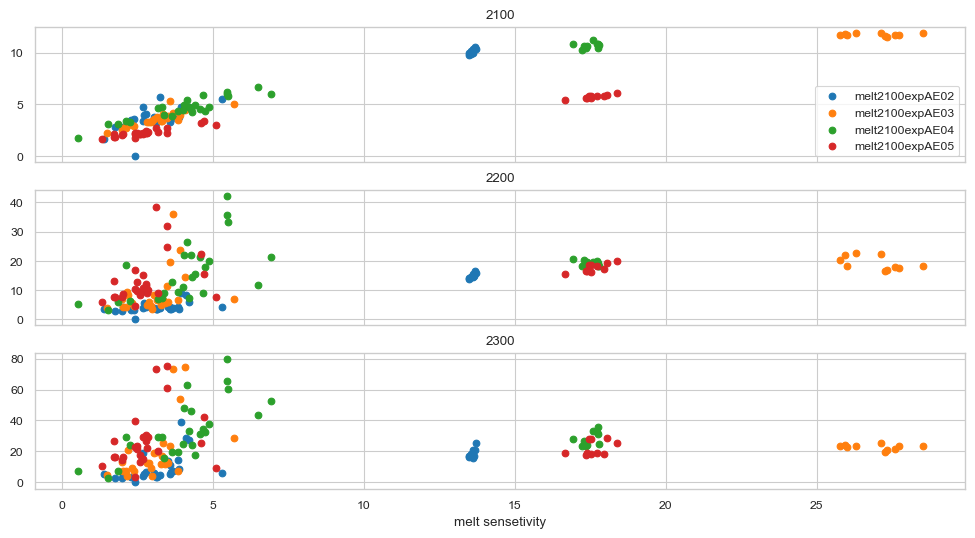

In [128]:
f,ax = plt.subplots(3,1, figsize = (12,6), sharex = True)
i =0
dftemp = df_m2100
exps = ['expAE02','expAE03','expAE04','expAE05']
for exp in exps:
    
    x = df_ms[df_ms['Experiment']== exp].AIS.values
    y =dftemp[dftemp['Experiment' ]== exp].AIS.values
    ax[i].scatter(x,y, label = 'melt2100' + exp)
    ax[i].set_title('2100')

i =1 
dftemp = df_m2200
for exp in exps:
    
    x = df_ms[df_ms['Experiment']== exp].AIS.values
    y =dftemp[dftemp['Experiment' ]== exp].AIS.values
    ax[i].scatter(x,y, label = 'melt2100' + exp)
    ax[i].set_title('2200')


i =2
dftemp = df_m2300
for exp in exps:
    
    x = df_ms[df_ms['Experiment']== exp].AIS.values
    y =dftemp[dftemp['Experiment' ]== exp].AIS.values
    ax[i].scatter(x,y, label = 'melt2100' + exp)
    ax[i].set_title('2300')

ax[0].legend()
ax[2].set_xlabel("melt sensetivity")

Text(0.5, 0, 'melt sensetivity')

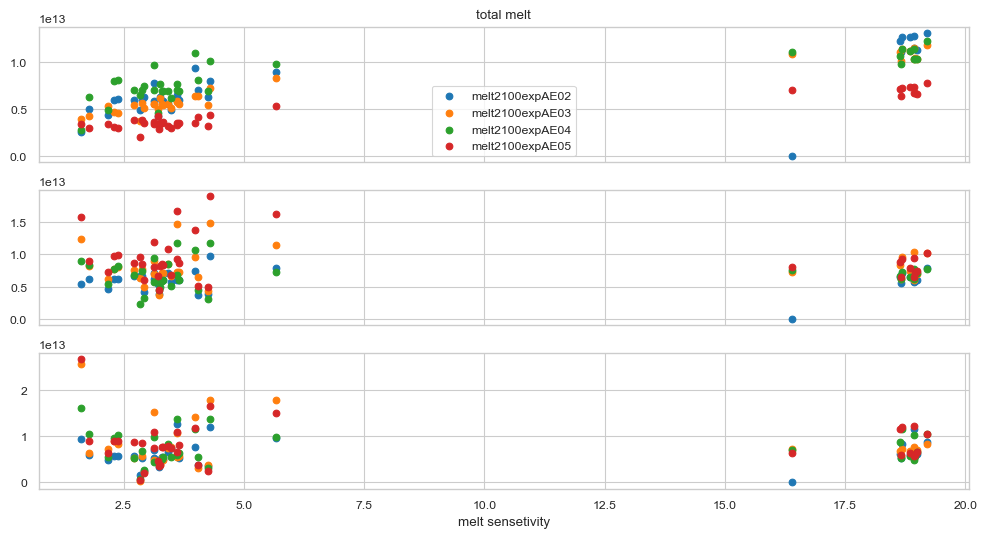

In [129]:
f,ax = plt.subplots(3,1, figsize = (12,6), sharex = True)
i =0
dftemp = df_bmb2100
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')
ax[0].set_title('total melt')
i =1 
dftemp = df_bmb2200
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')

i =2
dftemp = df_bmb2300
y =dftemp[dftemp['Experiment' ]== 'expAE02'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].AIS.values
ax[i].scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')
ax[0].legend()
ax[2].set_xlabel("melt sensetivity")

### maybe better relation ship between melt sensetivitiy and average shelf depth!

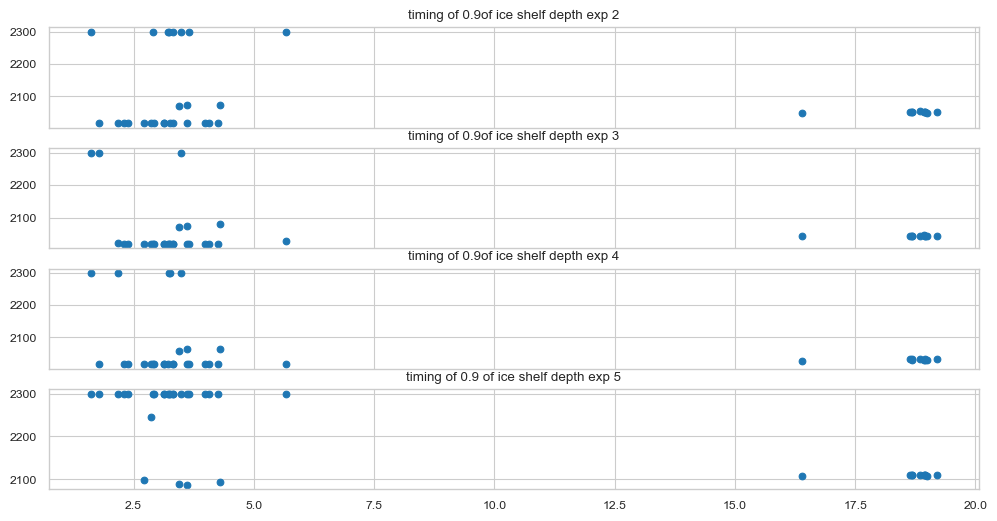

In [140]:
f,ax2 = plt.subplots(4,1, figsize = (12,6), sharex = True)
i =0
cfrac = 0.9
dftime= pd.read_csv('tables/time_'+str(cfrac)+'ofIceShelfdepth.csv')
dftemp = dftime
ax = ax2[0]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 2')
y =dftemp[dftemp['Experiment' ]== 'expAE02'].region_1.values
ax.scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
ax = ax2[1]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 3')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].region_1.values
ax.scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
ax = ax2[2]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 4')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].region_1.values
ax.scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
ax = ax2[3]
ax.set_title('timing of '+str(cfrac)+' of ice shelf depth exp 5')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].region_1.values
ax.scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')

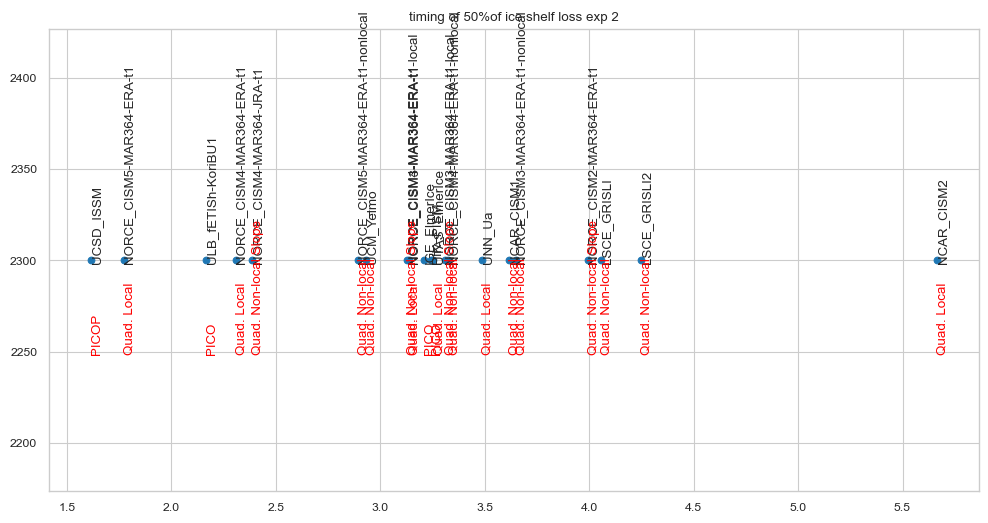

In [153]:
f,ax = plt.subplots(1,1, figsize = (12,6), sharex = True)
i =0
cfrac = 0.9
dftime= pd.read_csv('tables/time_'+str(cfrac)+'ofIceShelfdepth.csv')
dftemp = dftime
# ax = ax2[0]
ax.set_title('timing of 50%of ice shelf loss exp 2')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].region_1.values
m300 = y == 2300

ax.scatter(df_ms_mean.AIS.values[m300],y[m300], label = 'melt2100' + 'expAE02')

models_nofix = Models[m300].reset_index(drop=True)
meltp =melt_param[m300].reset_index(drop=True)
for j in range(len(y[m300])):
    
    ax.annotate(models_nofix[j],(df_ms_mean.AIS.values[m300][j],y[m300][j]),rotation = 90)
    ax.annotate(meltp[j],(df_ms_mean.AIS.values[m300][j],2250),color = 'red',rotation = 90)
    

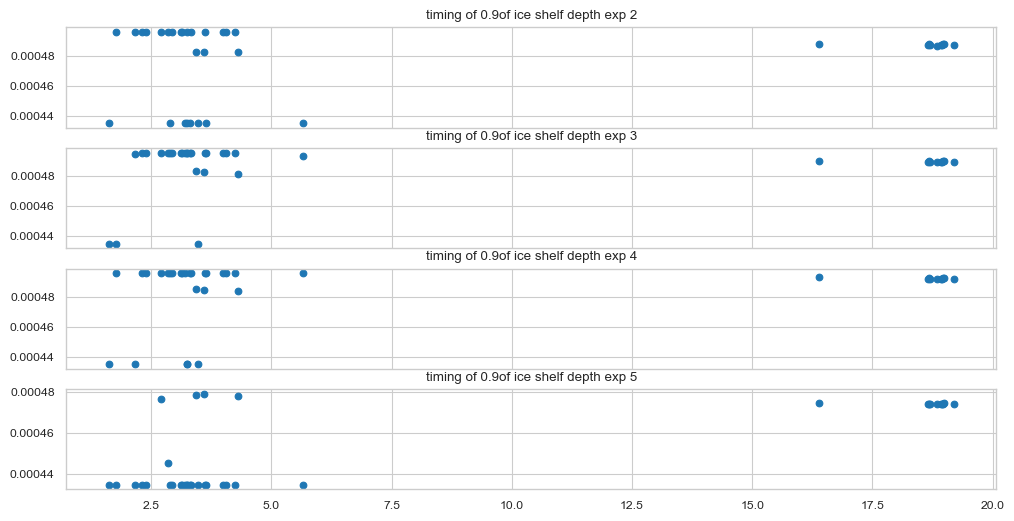

In [141]:
f,ax2 = plt.subplots(4,1, figsize = (12,6), sharex = True)
i =0
cfrac = 0.9
dftime= pd.read_csv('tables/time_'+str(cfrac)+'ofIceShelfdepth.csv')
dftemp = dftime
ax = ax2[0]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 2')
y =dftemp[dftemp['Experiment' ]== 'expAE02'].region_1.values
ax.scatter(df_ms_mean.AIS.values,1/y, label = 'melt2100' + 'expAE02')
ax = ax2[1]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 3')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].region_1.values
ax.scatter(df_ms_mean.AIS.values,1/y, label = 'melt2100' + 'expAE03')
ax = ax2[2]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 4')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].region_1.values
ax.scatter(df_ms_mean.AIS.values,1/y, label = 'melt2100' + 'expAE04')
ax = ax2[3]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 5')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].region_1.values
ax.scatter(df_ms_mean.AIS.values,1/y, label = 'melt2100' + 'expAE05')

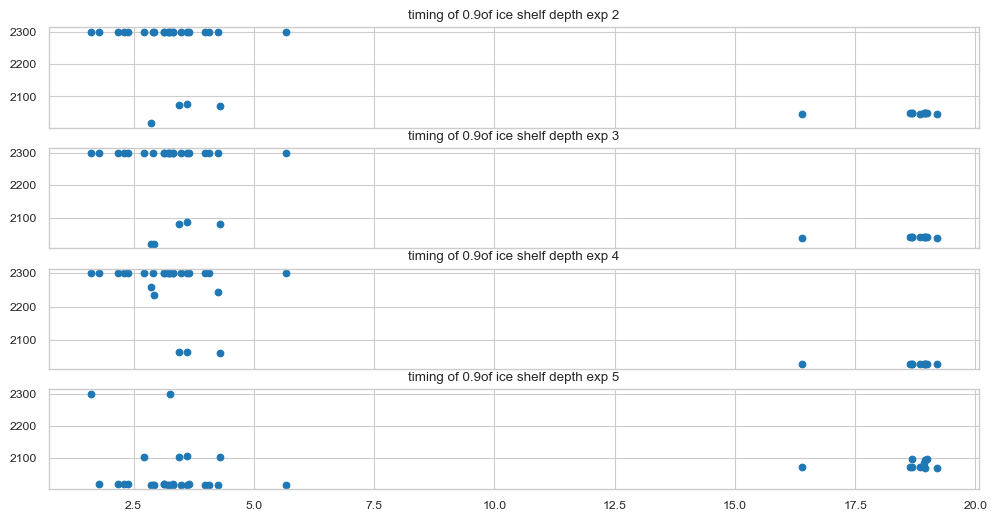

In [138]:
f,ax2 = plt.subplots(4,1, figsize = (12,6), sharex = True)
i =0
cfrac = 0.9
dftime= pd.read_csv('tables/time_'+str(cfrac)+'ofIceShelfdepth.csv')
dftemp = dftime
ax = ax2[0]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 2')
y =dftemp[dftemp['Experiment' ]== 'expAE02'].region_2.values
ax.scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE02')
ax = ax2[1]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 3')
y =dftemp[dftemp['Experiment' ]== 'expAE03'].region_2.values
ax.scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE03')
ax = ax2[2]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 4')
y =dftemp[dftemp['Experiment' ]== 'expAE04'].region_2.values
ax.scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE04')
ax = ax2[3]
ax.set_title('timing of '+str(cfrac)+'of ice shelf depth exp 5')
y =dftemp[dftemp['Experiment' ]== 'expAE05'].region_2.values
ax.scatter(df_ms_mean.AIS.values,y, label = 'melt2100' + 'expAE05')